# Random Forest Classification - Company Sales Analytics

### Project Description
This project analyzes company store-level sales data to identify the key business factors associated with **Low, Medium, and High Sales**. A Random Forest classification model is used because it can handle non-linear relationships and provide feature importance.

### Objective
To understand which store and market attributes influence sales performance, so the business can improve pricing, advertising, shelf placement, and store-level strategy.

### 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

### 2. Load Dataset

In [ ]:
DATA_PATH = Path('Sales-data.csv')
if not DATA_PATH.exists():
    DATA_PATH = Path('Sales-data.csv')

df = pd.read_csv(DATA_PATH)
df.head()

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


### 3. Data Understanding

In [3]:
print('Dataset shape:', df.shape)
print(); print('Columns:')
print(df.columns.tolist())
print(); print('Missing values:')
print(df.isnull().sum())
print(); print('Duplicate rows:', df.duplicated().sum())

Dataset shape: (400, 11)

Columns:
['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'ShelveLoc', 'Age', 'Education', 'Urban', 'US']

Missing values:
Sales          0
CompPrice      0
Income         0
Advertising    0
Population     0
Price          0
ShelveLoc      0
Age            0
Education      0
Urban          0
US             0
dtype: int64

Duplicate rows: 0


In [4]:
df.describe()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,7.496325,124.975000,68.657500,6.635000,264.840000,115.795000,53.322500,13.900000
std,2.824115,15.334512,27.986037,6.650364,147.376436,23.676664,16.200297,2.620528
min,0.000000,77.000000,21.000000,0.000000,10.000000,24.000000,25.000000,10.000000
25%,5.390000,115.000000,42.750000,0.000000,139.000000,100.000000,39.750000,12.000000
50%,7.490000,125.000000,69.000000,5.000000,272.000000,117.000000,54.500000,14.000000
75%,9.320000,135.000000,91.000000,12.000000,398.500000,131.000000,66.000000,16.000000
max,16.270000,175.000000,120.000000,29.000000,509.000000,191.000000,80.000000,18.000000


### 4. Target Variable Creation

The original `Sales` column is continuous. For classification, it is converted into three business categories:

- **Low Sales**: Sales below the first threshold
- **Medium Sales**: Sales in the middle range
- **High Sales**: Sales above the higher threshold

This makes the model useful for identifying stores that are likely to perform poorly, average, or strongly.

In [5]:
# Thresholds are based on the original project logic using sales distribution cut-offs.
df['Sales_Category'] = pd.cut(
    df['Sales'],
    bins=[0, 5.39, 9.32, 17],
    labels=['Low', 'Medium', 'High'],
    right=False,
    include_lowest=True
)

print(df['Sales_Category'].value_counts())

Sales_Category
Medium    198
High      102
Low       100
Name: count, dtype: int64


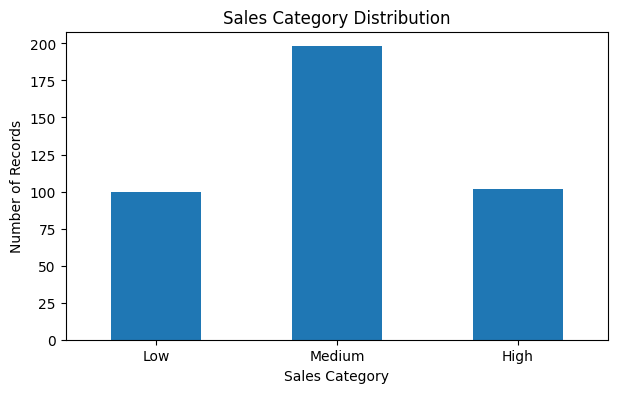

In [6]:
# Class distribution chart
class_counts = df['Sales_Category'].value_counts().reindex(['Low', 'Medium', 'High'])
class_counts.plot(kind='bar', figsize=(7,4))
plt.title('Sales Category Distribution')
plt.xlabel('Sales Category')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.show()

### 5. Exploratory Data Analysis

In [7]:
# Average values by sales category for business interpretation
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
df.groupby('Sales_Category')[numeric_cols].mean().round(2)

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
Sales_Category,,,,,,,,
Low,4.04,123.63,64.59,4.10,259.70,127.20,58.95,13.96
Medium,7.35,125.69,68.04,6.30,258.93,117.47,53.03,14.01
High,11.16,124.91,73.84,9.77,281.35,101.35,48.37,13.64


In [8]:
# Correlation with continuous Sales before converting to category
corr = df.drop(columns=['Sales_Category']).select_dtypes(include=['int64', 'float64']).corr()['Sales'].sort_values(ascending=False)
corr

Sales          1.000000
Advertising    0.269507
Income         0.151951
CompPrice      0.064079
Population     0.050471
Education     -0.051955
Age           -0.231815
Price         -0.444951
Name: Sales, dtype: float64

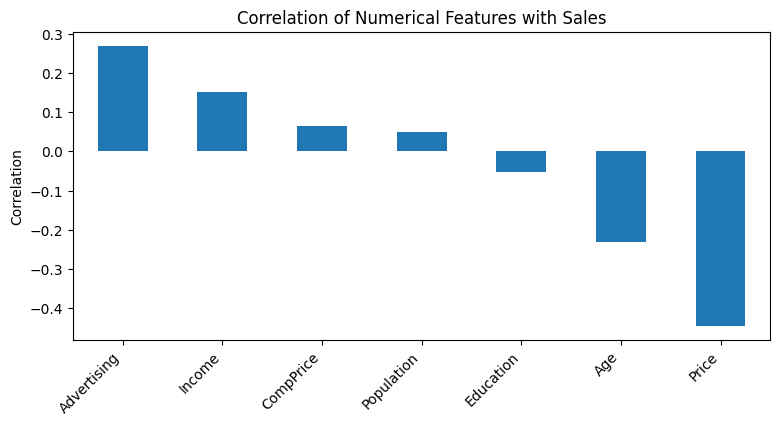

In [9]:
corr.drop('Sales').plot(kind='bar', figsize=(9,4))
plt.title('Correlation of Numerical Features with Sales')
plt.ylabel('Correlation')
plt.xticks(rotation=45, ha='right')
plt.show()

### 6. Preprocessing and Train-Test Split

The split is done before model training. Categorical variables are encoded inside a pipeline to keep the workflow clean and avoid data leakage.

In [10]:
X = df.drop(columns=['Sales', 'Sales_Category'])
y = df['Sales_Category'].astype(str)

categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('numerical', 'passthrough', numerical_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print('Training set:', X_train.shape)
print('Testing set :', X_test.shape)
print(); print('Training target distribution:')
print(y_train.value_counts())
print(); print('Testing target distribution:')
print(y_test.value_counts())

Training set: (280, 10)
Testing set : (120, 10)

Training target distribution:
Sales_Category
Medium    139
High       71
Low        70
Name: count, dtype: int64

Testing target distribution:
Sales_Category
Medium    59
High      31
Low       30
Name: count, dtype: int64


### 7. Baseline Random Forest Model

In [11]:
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight='balanced'
    ))
])

baseline_model.fit(X_train, y_train)
y_pred_base = baseline_model.predict(X_test)

print('Baseline Accuracy:', round(accuracy_score(y_test, y_pred_base), 4))
print('Baseline Macro F1:', round(f1_score(y_test, y_pred_base, average='macro'), 4))
print(); print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_base, labels=['Low', 'Medium', 'High']))
print(); print('Classification Report:')
print(classification_report(y_test, y_pred_base))

Baseline Accuracy: 0.6667
Baseline Macro F1: 0.6456

Confusion Matrix:
[[14 16  0]
 [ 8 48  3]
 [ 0 13 18]]

Classification Report:
              precision    recall  f1-score   support

        High       0.86      0.58      0.69        31
         Low       0.64      0.47      0.54        30
      Medium       0.62      0.81      0.71        59

    accuracy                           0.67       120
   macro avg       0.71      0.62      0.65       120
weighted avg       0.69      0.67      0.66       120



### 8. Cross-Validation

In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_accuracy = cross_val_score(baseline_model, X, y, cv=cv, scoring='accuracy', n_jobs=1)
cv_f1 = cross_val_score(baseline_model, X, y, cv=cv, scoring='f1_macro', n_jobs=1)

print('Mean CV Accuracy:', round(cv_accuracy.mean(), 4))
print('Mean CV Macro F1:', round(cv_f1.mean(), 4))

Mean CV Accuracy: 0.675
Mean CV Macro F1: 0.653


### 9. Hyperparameter Tuning

In [13]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [5, 8, 10, None],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': ['sqrt', 'log2'],
    'model__class_weight': ['balanced', None]
}

random_search = RandomizedSearchCV(
    estimator=baseline_model,
    param_distributions=param_grid,
    n_iter=4,
    cv=cv,
    scoring='f1_macro',
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train, y_train)

print('Best Parameters:')
print(random_search.best_params_)
print('Best CV Macro F1:', round(random_search.best_score_, 4))

Best Parameters:
{'model__n_estimators': 100, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': None, 'model__class_weight': None}
Best CV Macro F1: 0.6206


In [14]:
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print('Test Accuracy:', round(accuracy_score(y_test, y_pred), 4))
print('Test Macro F1:', round(f1_score(y_test, y_pred, average='macro'), 4))
print(); print('Confusion Matrix:')
print(confusion_matrix(y_test, y_pred, labels=['Low', 'Medium', 'High']))
print(); print('Classification Report:')
print(classification_report(y_test, y_pred))

Test Accuracy: 0.6417
Test Macro F1: 0.6176

Confusion Matrix:
[[13 17  0]
 [ 9 47  3]
 [ 0 14 17]]

Classification Report:
              precision    recall  f1-score   support

        High       0.85      0.55      0.67        31
         Low       0.59      0.43      0.50        30
      Medium       0.60      0.80      0.69        59

    accuracy                           0.64       120
   macro avg       0.68      0.59      0.62       120
weighted avg       0.66      0.64      0.63       120



### 10. Feature Importance

In [15]:
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()
importances = best_model.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

importance_df.head(10)

,Feature,Importance
11,numerical__Price,0.219894
12,numerical__Age,0.109032
1,categorical__ShelveLoc_Good,0.100165
0,categorical__ShelveLoc_Bad,0.095608
7,numerical__CompPrice,0.085612
9,numerical__Advertising,0.076607
10,numerical__Population,0.076259
8,numerical__Income,0.067740
2,categorical__ShelveLoc_Medium,0.058587
13,numerical__Education,0.053425


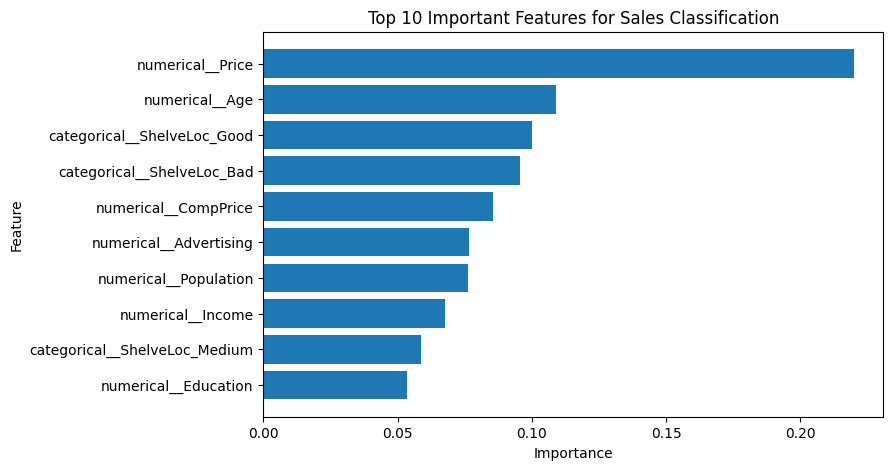

In [16]:
top_features = importance_df.head(10).sort_values('Importance')
plt.figure(figsize=(8,5))
plt.barh(top_features['Feature'], top_features['Importance'])
plt.title('Top 10 Important Features for Sales Classification')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### Observations

- The dataset has **400 records and 11 columns**, with no missing values and no duplicate rows.
- Sales was converted into **Low, Medium, and High** categories to make the problem suitable for classification.
- The target is moderately imbalanced, with the **Medium Sales** category having the highest number of records.
- The Random Forest model performs reasonably, but Medium Sales is easier to predict than Low and High Sales.
- The most important business drivers include **Price, Age, Shelf Location, Competitor Price, Income, Advertising, and Population**.
- Price and shelf placement are especially useful for business decision-making because they are directly actionable.

## Conclusion

The Random Forest model is useful for identifying the key factors that influence company sales categories. The model achieved around **65% test accuracy** and a **macro F1-score of around 0.63**, which is acceptable for a small business dataset of 400 records.

The analysis suggests that sales performance is strongly influenced by **pricing strategy, shelf location, competitor price, advertising, and customer demographics**. The business can use these insights to improve high-sales probability by optimizing price points, improving shelf placement, and focusing advertising efforts in suitable markets.